# Rossman Store Sales: Forecasting

In [1]:
%load_ext autoreload
%autoreload 2

In [69]:
import os
import sys
import warnings

# Add the parent directory (project root) to sys.path if not already there
parent_dir = os.path.dirname(os.getcwd())
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

warnings.filterwarnings("ignore")

In [ ]:
import warnings
import mlflow
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.core.display_functions import display

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import silhouette_score

from src.preprocessing import preprocess_rossmann_data

## Load datasets

In [4]:
DATA_PATH = "../data/"

train = pd.read_csv(f"{DATA_PATH}/train.csv", parse_dates=["Date"])
test = pd.read_csv(f"{DATA_PATH}/test.csv", parse_dates=["Date"])
store = pd.read_csv(f"{DATA_PATH}/store.csv")

train = train.merge(store, on="Store")
test = test.merge(store, on="Store")

print("Train dataset:")
display(train.head())
display(f"Train size: {train.shape}")

print("Test dataset:")
display(test.head())
display(f"Test size: {test.shape}")

Train dataset:


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


'Train size: (1017209, 18)'

Test dataset:


,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,1,4,2015-09-17,1.0,1,0,0,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,3,4,2015-09-17,1.0,1,0,0,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
2,3,7,4,2015-09-17,1.0,1,0,0,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
3,4,8,4,2015-09-17,1.0,1,0,0,a,a,7520.0,10.0,2014.0,0,NaN,NaN,NaN
4,5,9,4,2015-09-17,1.0,1,0,0,a,c,2030.0,8.0,2000.0,0,NaN,NaN,NaN


'Test size: (41088, 17)'

## Preprocessing

In [5]:
ptrain = preprocess_rossmann_data(df=train)
ptest = preprocess_rossmann_data(df=test)

ptrain.head(5)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,year,month,days_to_competitor
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,1270.0,9.0,2008.0,0,NaN,NaN,NaN,2015,7,2768
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,3133
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,3498
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,620.0,9.0,2009.0,0,NaN,NaN,NaN,2015,7,2402
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,29910.0,4.0,2015.0,0,NaN,NaN,NaN,2015,7,211


## Modeling

Build forecasting models for Rossmann stores

In [68]:
mlflow.set_tracking_uri("http://localhost:5001/")
mlflow.set_experiment("forecasting_rossmann_hybrid_clustering")

<Experiment: artifact_location='s3://mlflow-artifacts/9', creation_time=1777994873269, experiment_id='9', last_update_time=1777994873269, lifecycle_stage='active', name='forecasting_rossmann_hybrid_clustering', tags={}, trace_location=None, workspace='default'>

### (baseline) Modeling: Prophet

Building one model for each store is not feasible since it's 1110+ store.
Therefore, the initial idea is to **cluster stores and then build models for each cluster**. <br>
First, we build a profile (Avg. Sales and Avg. Customers) for each store. Then, we cluster store profiles.

It's important to mention that one model for all stores is also not possible since we learned from EDA
that we some store are quite different.

In [6]:
# Create a store profile
store_features = ptrain.groupby("Store").agg({
    "Sales": "mean",
    "Customers": "mean",
    "CompetitionDistance": "mean"
}).reset_index()

store_features = store_features.merge(store[["Store", "StoreType"]], on="Store")

store_features.columns = ['Store', 'AvgSales', 'AvgCustomers', "AvgCompetitionDistance", 'StoreType']
# Tested features: "SchoolHoliday", "Open", "Promo", "Promo2", 'StoreType'

display(store_features.head())

,Store,AvgSales,AvgCustomers,AvgCompetitionDistance,StoreType
0,1,3945.704883,467.646497,1270.0,c
1,2,4122.991507,486.045648,570.0,a
2,3,5741.253715,620.286624,14130.0,a
3,4,8021.769639,1100.057325,620.0,c
4,5,3867.110403,444.360934,29910.0,a


In [7]:
num_features = ["AvgSales", "AvgCustomers"]
cat_features = ["StoreType"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(), cat_features)
    ]
)

X_processed = preprocessor.fit_transform(store_features)

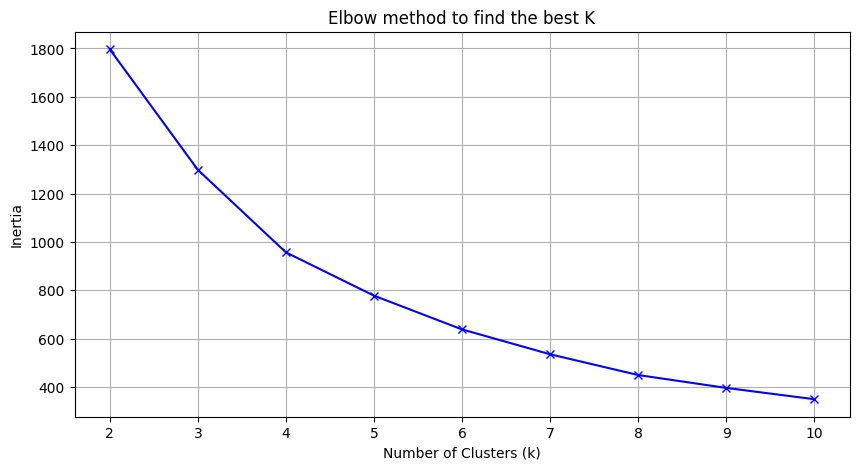

Silhouette scores:


{2: 0.4766256837305637,
 3: 0.3322185620054336,
 4: 0.40191892541792695,
 5: 0.47127705399623565,
 6: 0.45204740321966036,
 7: 0.4620760450667053,
 8: 0.44695612870700835,
 9: 0.46076497271348893,
 10: 0.4496019015853945}

In [8]:
inertia = []
scores = {}

K = range(2,11)

for k in K:
    kmodel = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmodel.fit(X_processed)
    inertia.append(kmodel.inertia_)
    score = silhouette_score(X_processed, kmodel.labels_)
    scores[k] = score

plt.figure(figsize=(10, 5))
plt.plot(K, inertia, 'bx-')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow method to find the best K")
plt.grid(True)
plt.show()

print("Silhouette scores:")
display(scores)

**Notes**
- According to Silhouette scores, *k=2* and *k=5* have good scores.
- *K=5* looks a bit overlapped when we plot the clusters.
- However, it's important to check the distribution of each cluster before jumping into modeling.

In [85]:
num_k = 5

kmeans = KMeans(n_clusters=num_k, random_state=42, n_init=10)
store_features["Cluster"] = kmeans.fit_predict(X_processed)

store_features.head()

,Store,AvgSales,AvgCustomers,AvgCompetitionDistance,StoreType,Cluster
0,1,3945.704883,467.646497,1270.0,c,3
1,2,4122.991507,486.045648,570.0,a,2
2,3,5741.253715,620.286624,14130.0,a,2
3,4,8021.769639,1100.057325,620.0,c,1
4,5,3867.110403,444.360934,29910.0,a,2


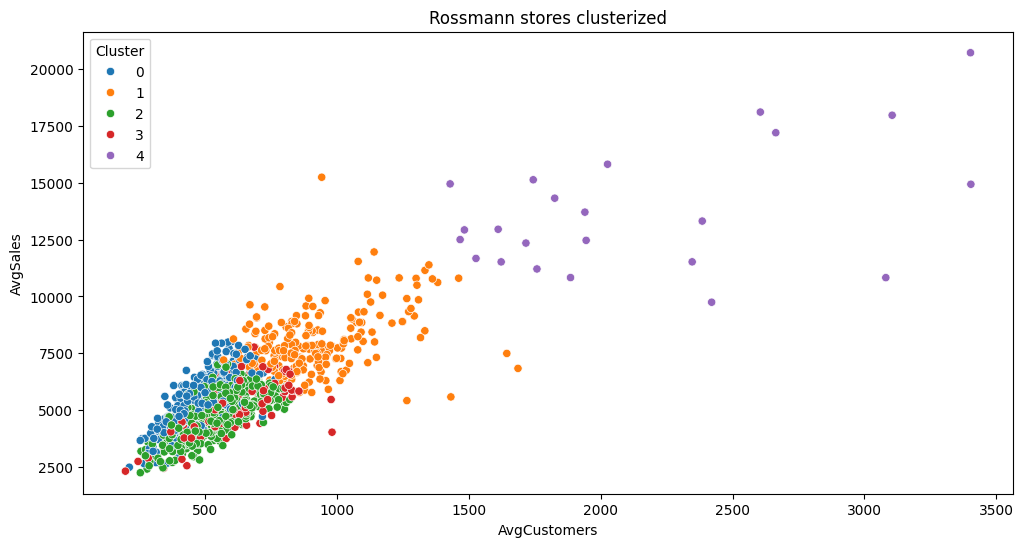

In [86]:
fig, ax = plt.subplots(figsize=(12,6))

cluster_colors = sns.color_palette("tab10")
sns.scatterplot(
    data=store_features,
    x="AvgCustomers",
    y="AvgSales",
    hue="Cluster",
    palette=cluster_colors
)
ax.set(title="Rossmann stores clusterized");


StoreType Distribution inside Clusters:


StoreType,a,b,c,d
Cluster,,,,
0,0,0,0,323
1,159,6,25,25
2,431,0,0,0
3,0,2,121,0
4,12,9,2,0


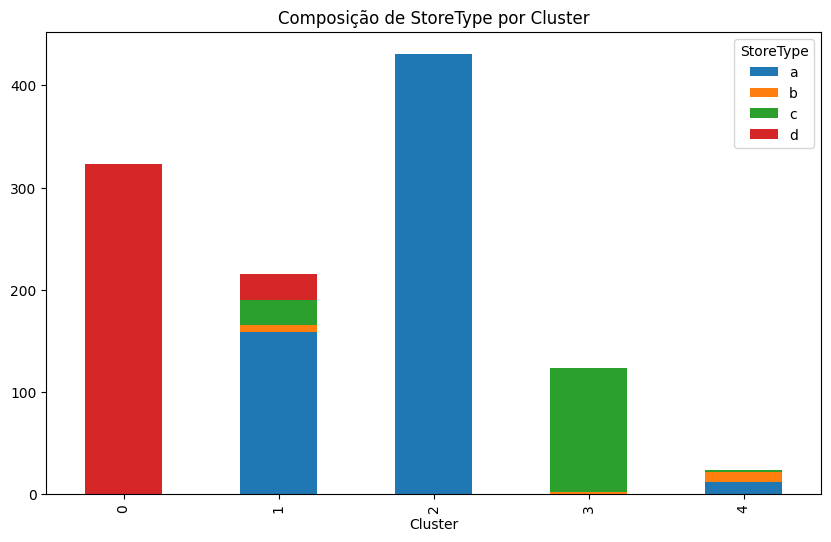

In [87]:
distribution_type = pd.crosstab(store_features['Cluster'], store_features['StoreType'])
print("\nStoreType Distribution inside Clusters:")
display(distribution_type)

distribution_type.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Composição de StoreType por Cluster')
plt.legend(title='StoreType')
plt.show()

Continue...

____